In [59]:
import os
import numpy as np
import keras
from keras import layers, callbacks
from tensorflow import data as tf_data
import tensorflow as tf
import matplotlib.pyplot as plt

In [60]:
DATA_DIR = "/home/andrew/dev/scrabbler/data/letters/processed_normalized/"
CLASS_NAMES = ["A","B","C","D","E","F","G","H","I","J","K","L","M","N","O","P","Q","R","S","T","U","V","W","X","Y","Z","BLANK"]
NUM_CLASSES = len(CLASS_NAMES)
BATCH_SIZE = 32 
IMAGE_SZ = (42, 42)
IMAGE_SHAPE = (42, 42, 3)

train_ds, val_ds = keras.utils.image_dataset_from_directory(
                        DATA_DIR,
                        labels="inferred",
                        label_mode="categorical",
                        class_names=CLASS_NAMES,
                        color_mode="rgb",
                        batch_size=BATCH_SIZE,
                        image_size=IMAGE_SZ,
                        shuffle=True,
                        seed=42,
                        validation_split=0.1,
                        subset="both",
                        follow_links=False,
                        verbose=True,
)

Found 970 files belonging to 27 classes.
Using 873 files for training.
Using 97 files for validation.


In [61]:
from collections import Counter

def count_ds(ds):
    c = Counter()
    for _, onehot in ds.unbatch():
        idx = int(np.argmax(onehot.numpy()))
        c[idx] += 1
    return c

train_counts = count_ds(train_ds)
val_counts   = count_ds(val_ds)

print("Train:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:5s}: {train_counts[i]}")
print("Val:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {cls:5s}: {val_counts[i]}")

Train:
  A    : 31
  B    : 34
  C    : 28
  D    : 34
  E    : 33
  F    : 31
  G    : 34
  H    : 31
  I    : 33
  J    : 31
  K    : 31
  L    : 34
  M    : 31
  N    : 31
  O    : 33
  P    : 29
  Q    : 35
  R    : 34
  S    : 32
  T    : 32
  U    : 34
  V    : 31
  W    : 33
  X    : 32
  Y    : 33
  Z    : 35
  BLANK: 33
Val:
  A    : 5
  B    : 1
  C    : 8
  D    : 2
  E    : 3
  F    : 5
  G    : 2
  H    : 5
  I    : 3
  J    : 4
  K    : 5
  L    : 3
  M    : 4
  N    : 6
  O    : 3
  P    : 7
  Q    : 1
  R    : 1
  S    : 4
  T    : 4
  U    : 2
  V    : 5
  W    : 3
  X    : 4
  Y    : 3
  Z    : 1
  BLANK: 3


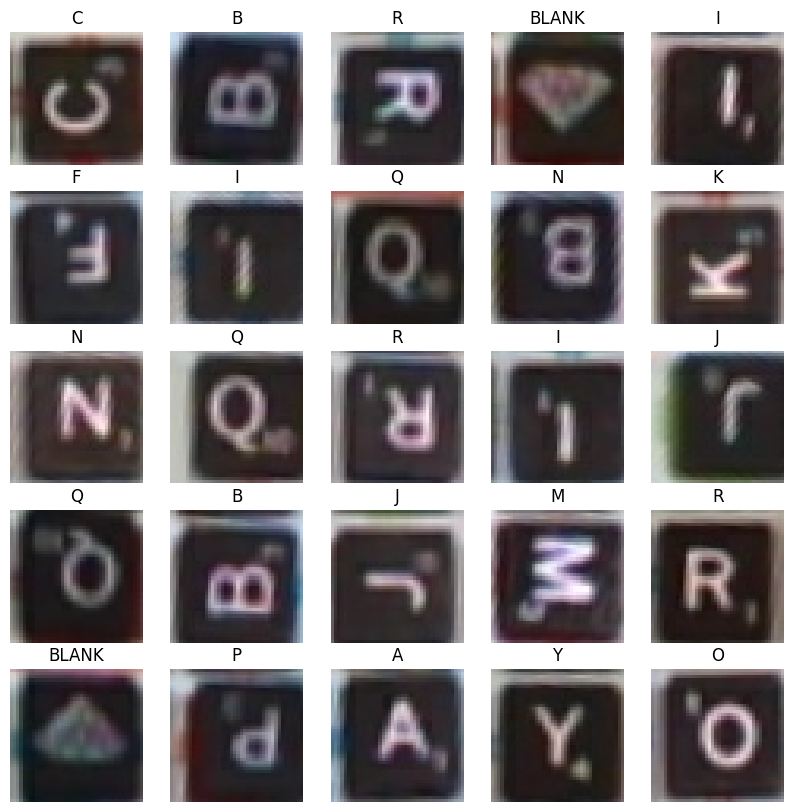

In [62]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(CLASS_NAMES[np.argmax(labels[i])])
        plt.axis("off")

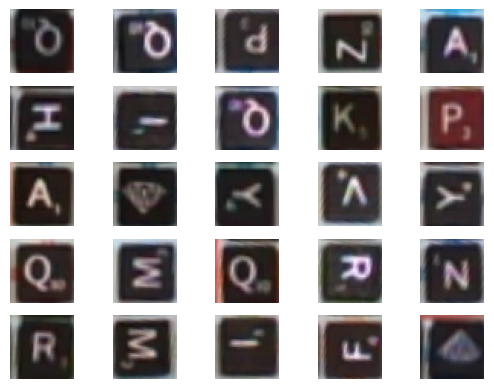

In [63]:
# Visualize original images before augmentation
for images, _ in train_ds.unbatch().batch(25).take(1):
    for i in range(min(25, len(images))):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")

In [64]:
augment = keras.Sequential(
    [
        layers.RandomContrast(0.6, value_range=(0.0, 255.0)),
        layers.RandomBrightness(0.3, value_range=(0.0, 255.0)),
        layers.RandomFlip("horizontal_and_vertical"),
    ],
    name="augment",
)
def cast_and_augment(img, label):
    img = tf.cast(img, tf.float32)                 # required dtype
    img = augment(img, training=True)              # force stochastic path
    return img, label

train_ds = (train_ds
            .map(cast_and_augment,
                 num_parallel_calls=tf.data.AUTOTUNE)
            .prefetch(tf.data.AUTOTUNE))

val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)

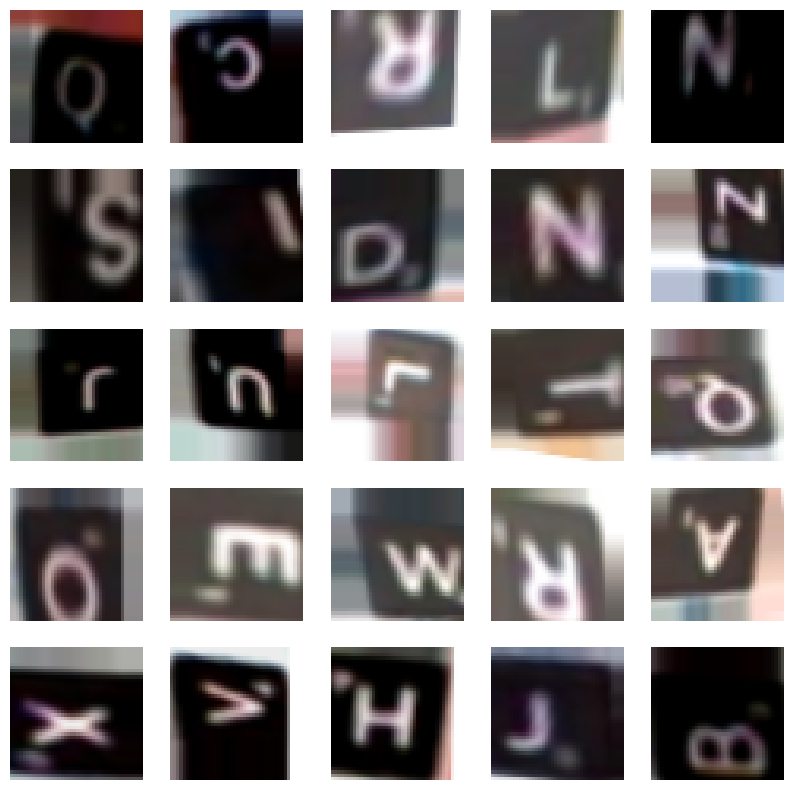

In [65]:
for images, _ in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(min(25, len(images))):
        ax = plt.subplot(5, 5, i + 1)
        # Display image directly without any further scaling
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")
    plt.show()

In [66]:
def build_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    
    x = layers.Conv2D(32, kernel_size=(5, 5), activation="relu")(inputs)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Conv2D(128, kernel_size=(3, 3), activation="relu")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(256, activation="relu")(x)
    
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    return keras.Model(inputs, outputs)

model = build_model(input_shape=IMAGE_SHAPE, num_classes=NUM_CLASSES)

In [69]:
EPOCHS = 300

callbacks = [
    keras.callbacks.ModelCheckpoint("train/models/tile/tile_e{epoch}.keras"),
    keras.callbacks.TensorBoard(log_dir="train/logs/tile")
]

model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)

model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    validation_data=val_ds,
)


Epoch 1/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - accuracy: 0.8569 - loss: 0.4490 - val_accuracy: 0.9897 - val_loss: 0.0565
Epoch 2/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8540 - loss: 0.5014 - val_accuracy: 0.9897 - val_loss: 0.0293
Epoch 3/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8460 - loss: 0.4856 - val_accuracy: 0.9794 - val_loss: 0.0280
Epoch 4/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8616 - loss: 0.4405 - val_accuracy: 0.9691 - val_loss: 0.0419
Epoch 5/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8750 - loss: 0.4465 - val_accuracy: 0.9897 - val_loss: 0.0330
Epoch 6/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8419 - loss: 0.4725 - val_accuracy: 0.9794 - val_loss: 0.0414
Epoch 7/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8625 - loss: 0.4153 - val_accuracy: 0.9794 - val_loss: 0.0717
Epoch 8/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8609 - loss: 0.4880 - val_accuracy: 0.9794 - 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9876 - loss: 0.0214 
Validation Loss: 0.031314339488744736
Validation Accuracy: 0.9793814420700073
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step


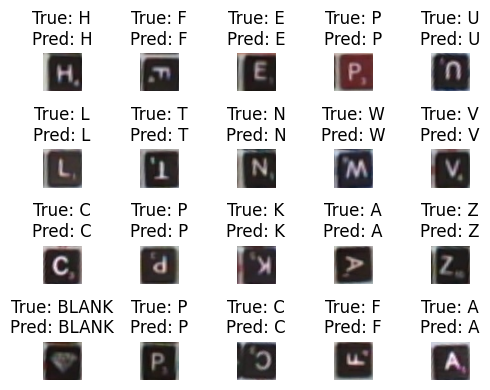

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import copy

# Evaluate the model on the validation set
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_acc}")

# Grab a batch of images and labels from the validation set
images, labels = next(iter(val_ds))

# Convert images to a NumPy array if needed
images = images.numpy() if isinstance(images, tf.Tensor) else images
images = images.astype(np.uint8)

# Make predictions on the batch
predictions = model.predict(images)
predicted_labels = np.argmax(predictions, axis=-1)

# If labels are one-hot encoded, convert them to integer labels for display
if labels.ndim > 1 and labels.shape[-1] > 1:
    true_labels = np.argmax(labels, axis=-1)
else:
    true_labels = labels

# Set up grid display for images (e.g., 4 rows x 5 columns for 20 images)
num_images_to_show = 20
num_rows, num_cols = 4, 5
plt.figure(figsize=(num_cols, num_rows))

for i in range(num_images_to_show):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(images[i])
    gt = CLASS_NAMES[int(true_labels[i])]
    pred = CLASS_NAMES[int(predicted_labels[i])]
    plt.title(f"True: {gt}\nPred: {pred}")
    plt.axis('off')

plt.tight_layout()
plt.show()
